# Post-Match Analysis Report

**Belgium vs France - Match Analysis**

This notebook provides a comprehensive post-match analysis using tracking and event data. The analysis covers:

1. **Data Overview and Pre-Processing** - Loading and preparing tracking/event data
2. **Defensive Behavior** - Defensive positioning and negative transitions
3. **Field Control** - Pitch control metrics and heatmaps
4. **Offensive Behavior** - Shot maps, passing networks, and box entries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
from matplotlib.patches import Rectangle, FancyArrowPatch, Polygon as PolygonPatch
from matplotlib.ticker import FuncFormatter
from mplsoccer import Pitch, VerticalPitch
from shapely.geometry import Point, MultiPoint, Polygon
from shapely.ops import voronoi_diagram
from collections import defaultdict
from tqdm.auto import tqdm
from PIL import Image
from io import BytesIO
import requests
import math

plt.rcParams['font.family'] = 'Bahnschrift'  # Set global font

# 1. Data Overview and Pre-Processing

In [ ]:
# ===== MATCH CONFIGURATION =====

# Data files
TRACKING_DATA_FILE = 'data/klopped_France_Belgium.pkl'
EVENT_DATA_FILE = 'data/bel_fra_events.pkl'

# Match details (for report generation)
MATCH_TITLE = "FRANCE 1 - 0 BELGIUM"
MATCH_SUBTITLE = "UEFA Euro 2024 - Round of 16"
MATCH_GOAL_INFO = "Vertonghen 85' (o.g.)"

# Team logos (URLs)
HOME_TEAM_LOGO_URL = "https://logos-world.net/wp-content/uploads/2024/06/France-National-Football-Team-Logo.png"
AWAY_TEAM_LOGO_URL = "https://logos-world.net/wp-content/uploads/2024/06/Belgium-National-Football-Team-Logo.png"

# Analysis settings
ANALYZED_TEAM_SIDE = 'away'  # 'home' or 'away' - which team to focus the analysis on
MAX_TIME_MINUTES = 63  # Time before substitutions (for position analysis)
COUNTERPRESS_TIME_WINDOW = 2  # Seconds to analyze after ball loss

# Formation/lineup text
FORMATION_TEXT = """1 - K. Casteels
21 - T. Castagne (88' C. De Ketelaere)
4 - W. Faes
5 - J. Vertonghen
3 - A. Theate
11 - Y. Carrasco (88' D. Lukebakio)
24 - A. Onana
7 - K. De Bruyne
22 - J. Doku
10 - R. Lukaku
20 - L. Openda (64' O. Mangala)"""

## 1.1 Tracking Data

In [6]:
# Load tracking data
df = pd.read_pickle(TRACKING_DATA_FILE)

# Automatically detect team names from the data
all_teams = df['ball_owning_team_id'].value_counts()
if len(all_teams) >= 2:
    home_team = all_teams.index[0]
    away_team = all_teams.index[1]
else:
    raise ValueError("Could not detect two teams in the data")

# Set which team we're analyzing based on configuration
ANALYZED_TEAM = away_team if ANALYZED_TEAM_SIDE == 'away' else home_team
OPPONENT_TEAM = home_team if ANALYZED_TEAM_SIDE == 'away' else away_team

print(f"Data loaded: {TRACKING_DATA_FILE}")
print(f"Detected teams: {home_team} (home) vs {away_team} (away)")
print(f"Analyzing: {ANALYZED_TEAM}")

Data loaded: data/klopped_France_Belgium.pkl
Detected teams: France (home) vs Belgium (away)
Analyzing: Belgium


Convert timestamp to milliseconds format:

In [7]:
df['timestamp'] = df['timestamp'].astype('timedelta64[ms]')  # Ensures it's in milliseconds
df['timestamp'] = df['timestamp'].apply(lambda x: str(x)[7:])  # Removes '0 days '

Center coordinates to UEFA standard (105x68, origin at bottom-left):

In [8]:
def shift_coordinates(df):
    for column in df.columns:
        if column.endswith('_x'):
            df[column] = df[column] + 52.5
        elif column.endswith('_y'):
            df[column] = df[column] + 34
            
    return df 

df_shifted = shift_coordinates(df)

Invert attack direction to align with event data:

In [9]:
def switch_direction(df):
	for column in df.columns:
		if column.endswith('_x'):
			df[column] = 105 - df[column]
			
	for column in df.columns:
		if column.endswith('_y'):
			df[column] = 68 - df[column]
	return df

df_shifted = switch_direction(df_shifted)
df_shifted.head()

,period_id,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y,ball_z,ball_speed,home_Mike Maignan_x,...,away_Orel Mangala_d,away_Orel Mangala_s,away_Dodi Lukebakio_x,away_Dodi Lukebakio_y,away_Dodi Lukebakio_d,away_Dodi Lukebakio_s,away_Charles De Ketelaere_x,away_Charles De Ketelaere_y,away_Charles De Ketelaere_d,away_Charles De Ketelaere_s
0,1,00:00:00,0,In,France,52.499020,34.014927,0.146819,0.155962,100.893734,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,00:00:00.040000,1,In,France,52.958825,33.948746,0.163715,11.621257,100.887302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,00:00:00.080000,2,In,France,53.432419,33.893763,0.165214,11.919448,100.877075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,00:00:00.120000,3,In,France,53.896868,33.843189,0.166703,11.679919,100.866749,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,00:00:00.160000,4,In,France,54.355448,33.790131,0.156743,11.543661,100.856773,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Create player number mapping for visualization:

In [10]:
# Automatically extract player names and create mapping
def extract_player_mapping(df):
    """
    Extract player names from dataframe column names and create a mapping.
    Assign sequential numbers to players for visualization.
    """
    player_mapping = {}
    counter = 1
    
    # Extract unique player names from column names
    for col in df.columns:
        if col.startswith(('home_', 'away_')) and col.endswith(('_x', '_y', '_d', '_s')):
            # Remove prefix and suffix to get player name
            player_name = col.replace('home_', '').replace('away_', '')
            player_name = player_name.rsplit('_', 1)[0]  # Remove last underscore and what follows
            
            if player_name not in player_mapping and player_name != 'ball':
                player_mapping[player_name] = counter
                counter += 1
    
    return player_mapping

player_mapping = extract_player_mapping(df_shifted)
print(f"Found {len(player_mapping)} players")
print("Player mapping:", player_mapping)

Found 26 players
Player mapping: {'Mike Maignan': 1, 'Adrien Rabiot': 2, "N'Golo Kante": 3, 'Marcus Thuram': 4, 'William Saliba': 5, 'Theo Hernandez': 6, 'Antoine Griezmann': 7, 'Dayot Upamecano': 8, 'Kylian Mbappe': 9, 'Aurelien Tchouameni': 10, 'Jules Kounde': 11, 'Koen Casteels': 12, 'Romelu Lukaku': 13, 'Lois Openda': 14, 'Timothy Castagne': 15, 'Wout Faes': 16, 'Jan Vertonghen': 17, 'Yannick Carrasco': 18, 'Arthur Theate': 19, 'Jeremy Doku': 20, 'Kevin De Bruyne': 21, 'Amadou Onana': 22, 'Randal Kolo Muani': 23, 'Orel Mangala': 24, 'Dodi Lukebakio': 25, 'Charles De Ketelaere': 26}


Verify setup by plotting initial player positions:

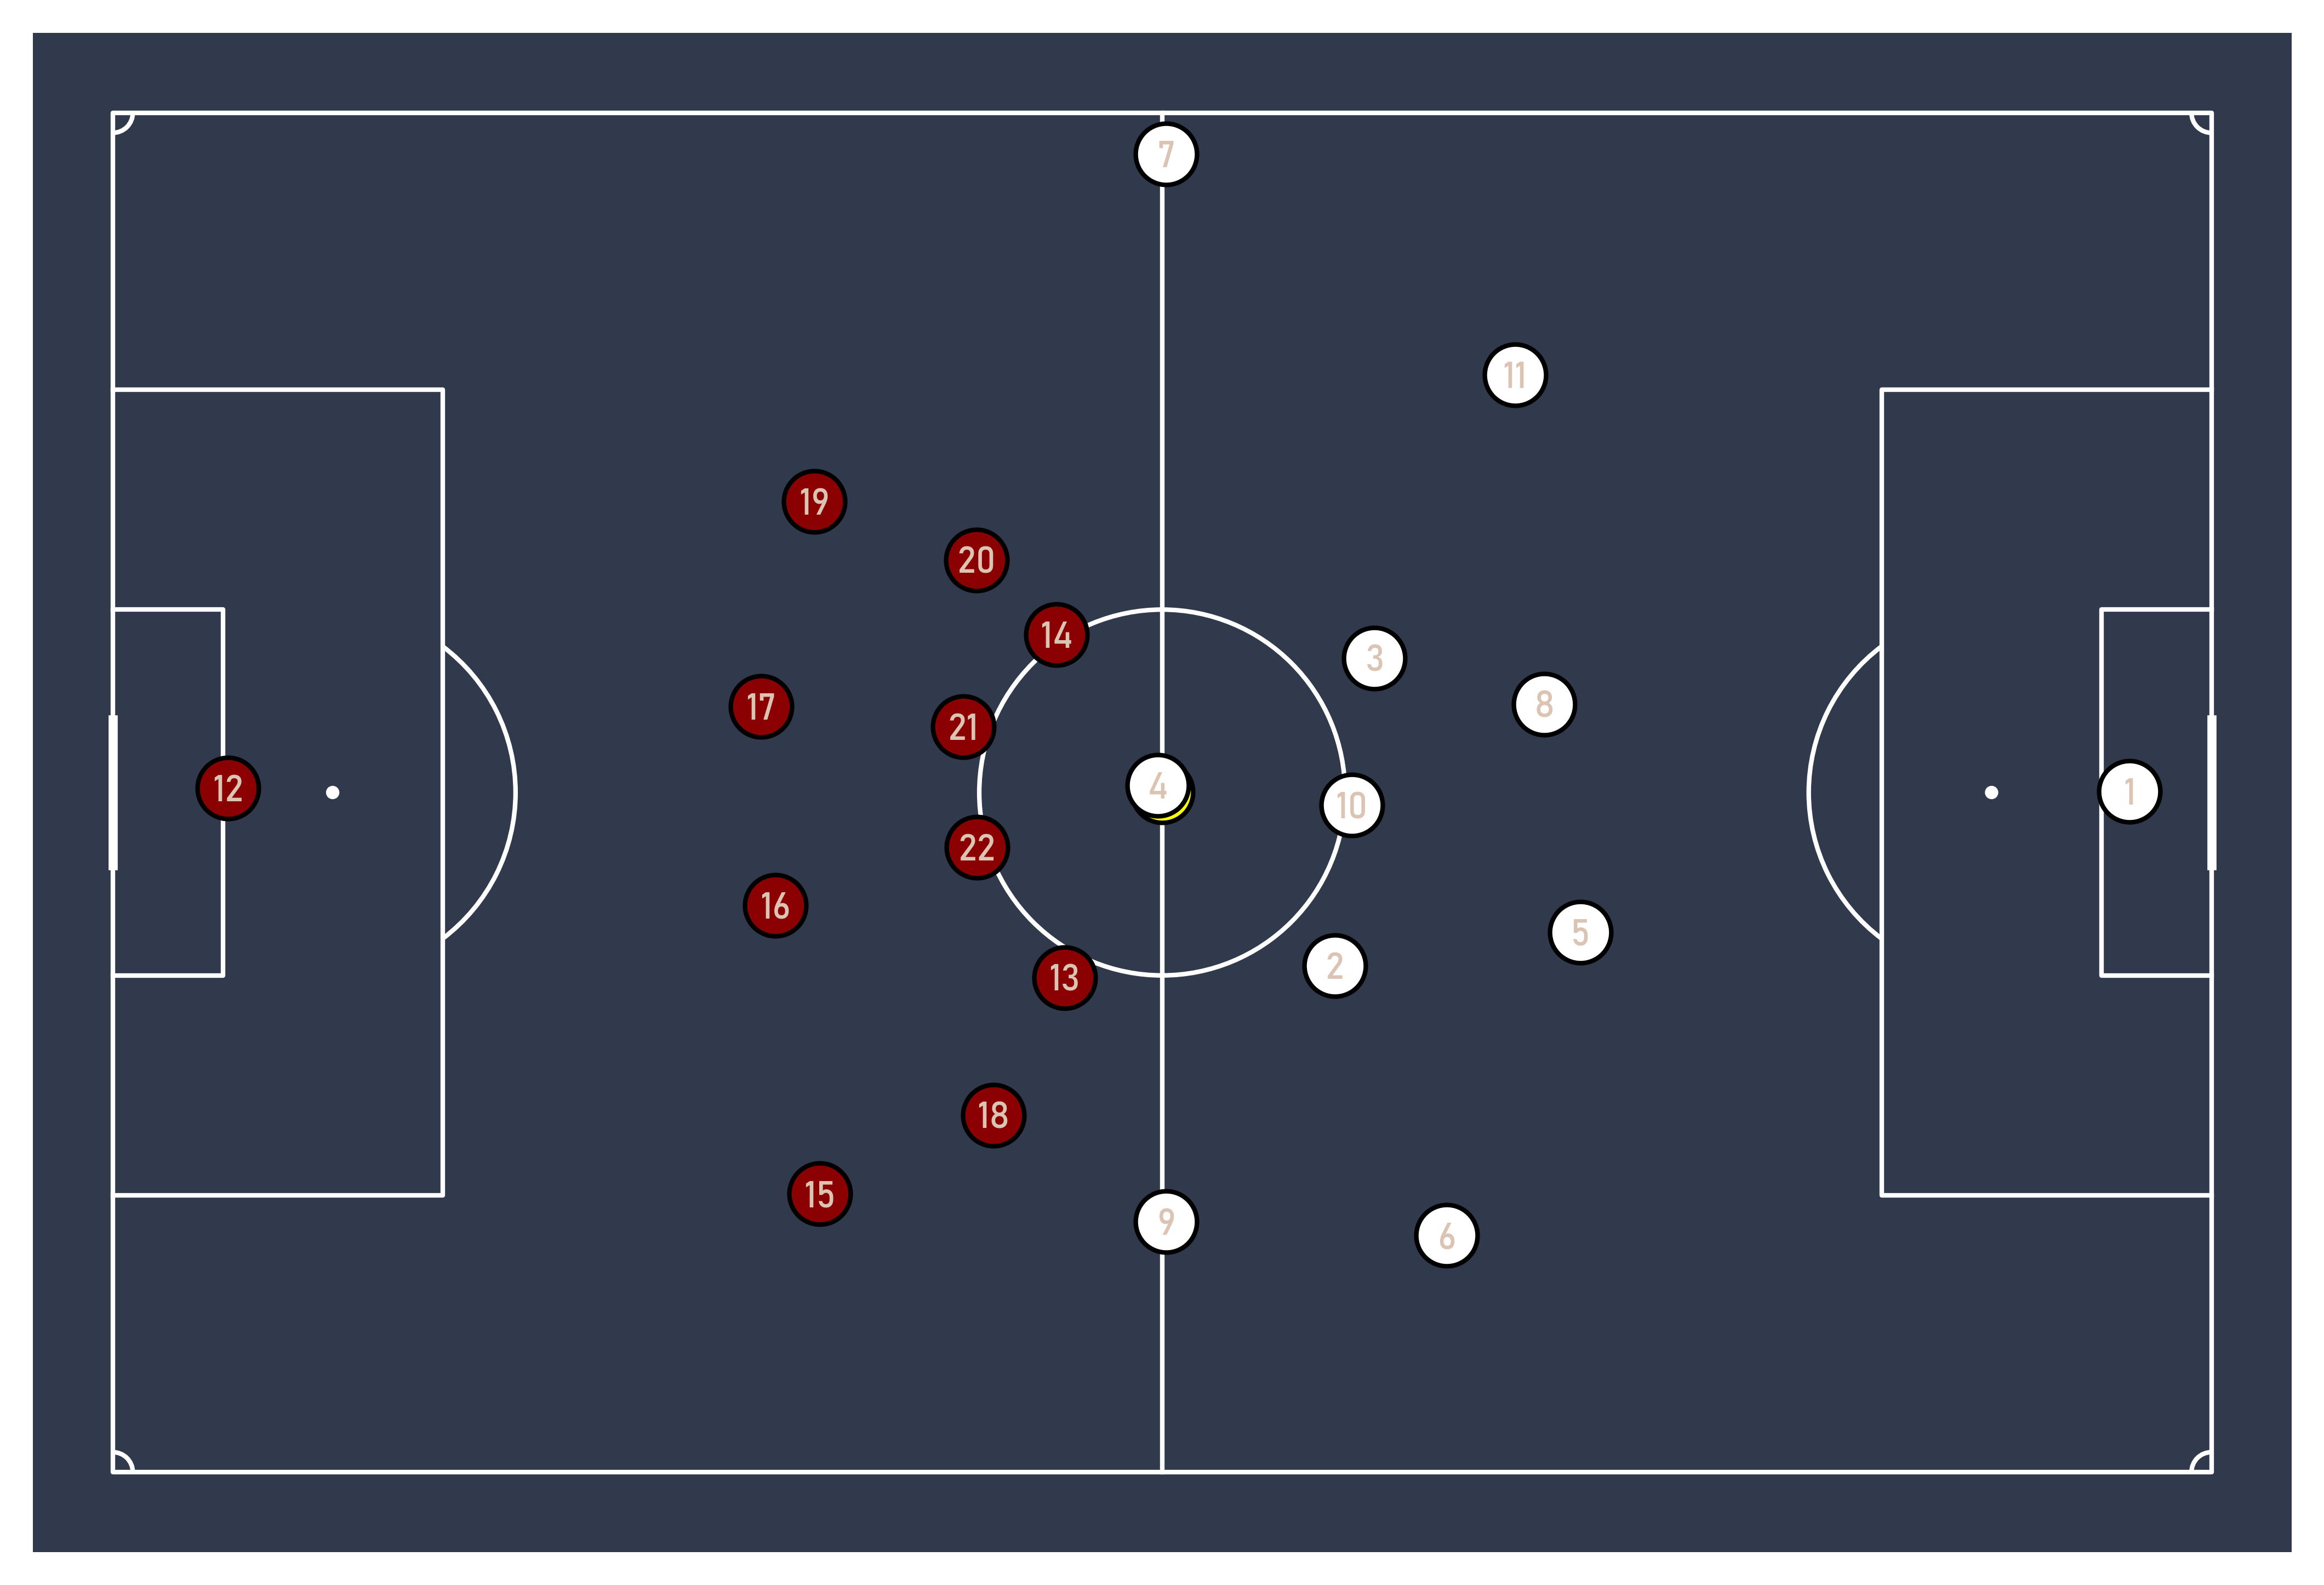

In [11]:
df_timestamp_0 = df_shifted.iloc[[0]]

player_x_columns = [col for col in df_shifted.columns if col.endswith('_x')]
player_y_columns = [col for col in df_shifted.columns if col.endswith('_y')]

pitch = Pitch(pitch_type='uefa', pitch_color='#31394d', line_color='white', linewidth=1, corner_arcs=True, line_zorder=2)
fig, ax = plt.subplots(figsize=(10, 6), dpi=600)  
pitch.draw(ax=ax) 

for col_x, col_y in zip(player_x_columns, player_y_columns):
    player_name = col_x.split('_x')[0].replace("home_", "").replace("away_", "")
    x_coord = df_timestamp_0[col_x].values[0]  
    y_coord = df_timestamp_0[col_y].values[0] 

    if pd.notna(x_coord) and pd.notna(y_coord):
        dot_color = 'white' if col_x.startswith('home') else '#8B0000' if col_x.startswith('away') else 'yellow'

        pitch.scatter(x_coord, y_coord, color=dot_color, edgecolors="black", ax=ax, s=180, zorder=3)

        player_number = player_mapping.get(player_name, "")

        ax.text(x_coord, y_coord, str(player_number), color='#dcc4b4', fontsize=8, fontweight="bold", ha='center', va='center_baseline', zorder=4)

plt.show()

## 1.2 Event Data

In [12]:
df_event = pd.read_pickle(EVENT_DATA_FILE)

# Detect possession team from event data (should match tracking data)
print(f"Event data teams: {df_event['possession_team'].unique()}")

Event data teams: ['France' 'Belgium']


In [13]:
# Split location feature in two colums
df_event['location_x'] = df_event['location'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else None)
df_event['location_y'] = df_event['location'].apply(lambda x: x[1] if isinstance(x, (list, np.ndarray)) else None)

# Rescale from 120x80 to 105x68 and switch direction
df_event['location_x'] = (df_event['location_x'] * 105 / 120) 
df_event['location_y'] = 68 - (df_event['location_y'] * 68 / 80)

# Same for pass end location
df_event['pass_end_location_x'] =df_event['pass_end_location'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else None)
df_event['pass_end_location_y'] =df_event['pass_end_location'].apply(lambda x: x[1] if isinstance(x, (list, np.ndarray)) else None)

df_event['pass_end_location_x'] = (df_event['pass_end_location_x'] * 105 / 120)
df_event['pass_end_location_y'] = 68 - (df_event['pass_end_location_y'] * 68 / 80)

# 2. Defensive Behavior

### Average Defensive Positioning

Analyze team shape when opponent has possession in the defensive third.

The defensive positions are computed until minute 63 (first substitution). This shows Belgium's defensive shape when France had the ball in Belgium's defensive third.

In [14]:
max_time = pd.Timedelta(minutes=63)  # Before the first substitution

def average_position_defense(df, max_time, attacking_team, defending_team, team_prefix='away'):
	"""
	Calculate average defensive positions when a team is defending.
	
	Args:
		df: DataFrame with tracking data
		max_time: Maximum time to consider (to exclude substitutions)
		attacking_team: Name of the attacking team
		defending_team: Name of the defending team
		team_prefix: 'home' or 'away' for the defending team
	"""
	df['timestamp'] = pd.to_timedelta(df['timestamp']) # Convert to timedelta
	
	df_filtered = df[(df['ball_state'] == 'In') & 
	                 (df['ball_owning_team_id'] == attacking_team) & 
	                 (df['ball_x'] < 35) & 
	                 (df['timestamp'] < max_time)]
	# Ball is in play, attacking team has the ball, and the ball is on the defending third 
	
	average_positions = {}
	std_positions = {}

	player_x_columns = [col for col in df_filtered.columns if col.startswith(f'{team_prefix}_') and col.endswith('_x')]
	player_y_columns = [col for col in df_filtered.columns if col.startswith(f'{team_prefix}_') and col.endswith('_y')]

	for col_x, col_y in zip(player_x_columns, player_y_columns):
		player_name = col_x.split('_x')[0]  
		
		total_x = df_filtered[col_x].sum()
		total_y = df_filtered[col_y].sum()
		count = df_filtered[col_x].count()  
		
		if count > 0:
			avg_x = total_x / count
			avg_y = total_y / count
			std_x = df_filtered[col_x].std()
			std_y = df_filtered[col_y].std()
			average_positions[player_name] = (avg_x, avg_y)
			std_positions[player_name] = (std_x, std_y)
		else:
			average_positions[player_name] = (None, None)
			std_positions[player_name] = (None, None)
	
	return average_positions, std_positions

# Calculate defensive positions for away team (Belgium in original example)
avg_positions, std_positions = average_position_defense(df_shifted, max_time, home_team, away_team, 'away')

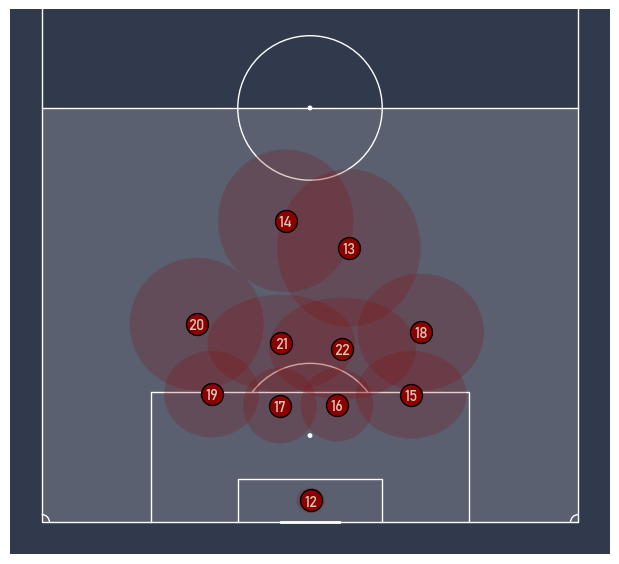

In [15]:
pitch = VerticalPitch(pitch_type='uefa',pad_top = -40, pitch_color='#31394d', line_color='white', corner_arcs=True, linewidth=1)
fig1, ax = plt.subplots(figsize=(6, 16))
pitch.draw(ax=ax)

for player, (avg_x, avg_y) in avg_positions.items():
    if avg_x is not None and avg_y is not None:
        
        player_name = player.replace("home_", "").replace("away_", "")
        
        pitch.scatter(avg_x, avg_y, color='#8B0000', s=250, edgecolors='black', label=player_name, ax=ax, zorder=3)
        
        std_x, std_y = std_positions[player]  # Get standard deviations for x and y
        
        ellipse = patches.Ellipse((avg_y, avg_x), width=std_y*1.7, height=std_x*1.7, 
                                  edgecolor='none', facecolor='#8B0000', alpha=0.20, linewidth=2, zorder=2)
        ax.add_patch(ellipse)
  
        player_number = player_mapping.get(player_name, "")  
        ax.text(avg_y, avg_x, str(player_number), color='#dcc4b4', fontsize=11, fontweight="bold", 
                ha='center', va='center_baseline', zorder=4)

box = patches.Rectangle((0, 0), 68, 52.5, linewidth=0, edgecolor='none', facecolor='white', alpha=0.2)
ax.add_patch(box)

plt.tight_layout(pad=0) 
plt.savefig("figures/defensive_shape.png", format="png", dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

## 2.1 Negative Transitions

Analyze average positions during negative transitions (when possession is lost).

**Algorithm:**
1. Filter for ball in play in opponent's half
2. Identify moments where opponent gains possession
3. Calculate average position of each player within time threshold after losing ball

In [16]:
def average_position_transitions(df, max_time, time_threshold, losing_team, gaining_team, team_prefix='away'):
    """
    Calculate average positions during negative transitions (when possession is lost).
    
    Args:
        df: DataFrame with tracking data
        max_time: Maximum time to consider
        time_threshold: Seconds after ball loss to measure
        losing_team: Team that loses possession
        gaining_team: Team that gains possession
        team_prefix: 'home' or 'away' for the team losing possession
    """
    df = df.copy()
    df['timestamp'] = pd.to_timedelta(df['timestamp']) 
    df['previous_possession'] = df['ball_owning_team_id'].shift(1)
    
    df_filtered = df.loc[(df['ball_state'] == 'In') & (df['timestamp'] < max_time)].copy()
    
    # Identify transition events: losing_team loses the ball to gaining_team in the offensive third
    df_filtered['ball_lost'] = ((df_filtered['previous_possession'] == losing_team) & 
    (df_filtered['ball_owning_team_id'] == gaining_team) & (df_filtered['ball_x'] > 52.5) )
    
    player_x_cols = [col for col in df_filtered.columns if col.startswith(f'{team_prefix}_') and col.endswith('_x')]
    player_y_cols = [col.replace('_x', '_y') for col in player_x_cols]
    player_cols = list(zip(player_x_cols, player_y_cols))
    
    # Average positions at ball loss
    df_lost = df_filtered[df_filtered['ball_lost']]
    average_positions = {
        col_x.split('_x')[0]: (df_lost[col_x].mean(), df_lost[col_y].mean())
        for col_x, col_y in player_cols
    }
    
    # Future average positions
    future_positions = {player: [] for player in average_positions}
    
    for _, row in df_lost.iterrows():
        future_time = row['timestamp'] + pd.Timedelta(seconds=time_threshold)
        df_future = df_filtered[(df_filtered['ball_owning_team_id'] == gaining_team) &
                                (df_filtered['timestamp'] == future_time)]
        
        for col_x, col_y in player_cols:
            player_name = col_x.split('_x')[0]
            if not df_future.empty:
                future_positions[player_name].append((df_future[col_x].mean(), df_future[col_y].mean()))
            else:
                future_positions[player_name].append((None, None))
    
    # Mean future positions
    average_positions_future = {
        player: (pd.Series([x for x, y in pos if x is not None]).mean(),
                 pd.Series([y for x, y in pos if y is not None]).mean())
        if any(x is not None for x, y in pos) else (None, None)
        for player, pos in future_positions.items()
    }
    
    return average_positions, average_positions_future

max_time = pd.Timedelta(minutes=63)
a, b = average_position_transitions(df_shifted, max_time, 2, away_team, home_team, 'away')

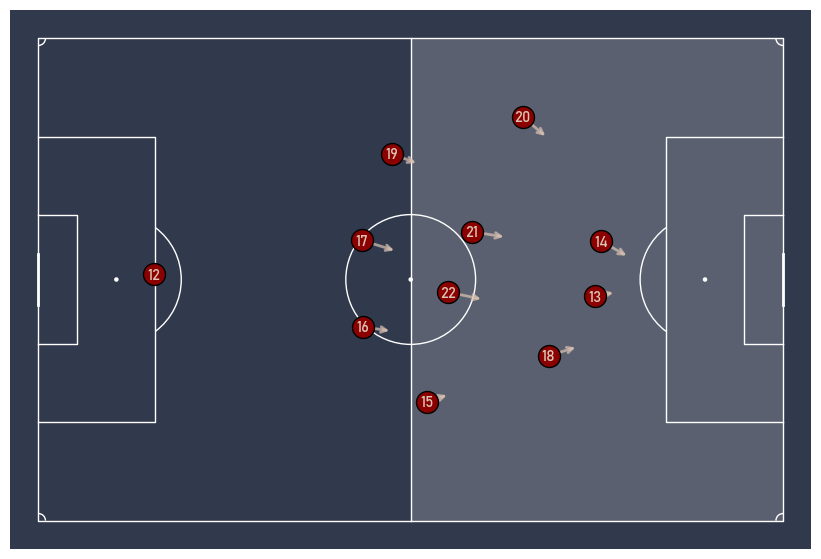

In [17]:
pitch = Pitch(pitch_type='uefa', pitch_color='#31394d', line_color='white', linewidth=1, corner_arcs=True, line_zorder=2)
fig, ax = plt.subplots(figsize=(12, 7))  
pitch.draw(ax=ax)

box = patches.Rectangle((52.5, 0), 52.5, 68, linewidth=0, edgecolor='none', facecolor='white', alpha=0.2)
ax.add_patch(box)

for col_x in a.keys():
    player_name = col_x.split('_x')[0].replace("home_", "").replace("away_", "") 
    x_a, y_a = a[col_x]

    if np.isfinite(x_a) and np.isfinite(y_a):
        x_b, y_b = b.get(col_x, (None, None))

        if np.isfinite(x_b) and np.isfinite(y_b):
            pitch.annotate('', xy=(x_b, y_b), xytext=(x_a, y_a),
                           arrowprops=dict(facecolor='orange', edgecolor='#dcc4b4', alpha=0.7, lw=2, arrowstyle='->'),
                           ax=ax)

        pitch.scatter(x_a, y_a, color='#8B0000', s=250, edgecolors='black', ax=ax, zorder=3)

        player_number = player_mapping.get(player_name, "")
        ax.text(x_a, y_a, str(player_number), color='#dcc4b4', fontsize=11, fontweight="bold", ha='center', va='center_baseline', zorder=4)

plt.savefig("figures/transitions.png", format="png", dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


**Observation:** The plot suggests a tendency to press towards the middle when the ball is lost in the opponent's half (within 2 seconds).

# 3. Field Control

## 3.1 Pitch Control Index

Calculate pitch control using Voronoi diagrams and nearest neighbors. At each timestamp, determine the proportion of the pitch controlled by each team based on player positions.

In [18]:

def is_valid_point(p):
    return isinstance(p, (list, tuple)) and len(p) == 2 and all(isinstance(c, (int, float)) and not math.isnan(c) for c in p)

def constrained_voronoi(teams_dict, envelope):
    home_players = [p for p in teams_dict['home'] if is_valid_point(p)]
    away_players = [p for p in teams_dict['away'] if is_valid_point(p)]
    all_points = home_players + away_players
    
    # Filter out duplicate points to avoid errors
    unique_points = list(set(all_points))
    
    point_geoms = [Point(p) for p in unique_points]
    
    # Generate Voronoi diagram. Envelope = pitch boundaries
    voronoi = voronoi_diagram(MultiPoint(point_geoms), envelope=envelope, edges=False)
    
    # Assign colors
    colors = ['red'] * len(home_players) + ['blue'] * len(away_players)
    point_to_color = {tuple(p): c for p, c in zip(all_points, colors)}
    
    clipped_voronoi = []
    cell_colors = []
    
    for poly in voronoi.geoms:
        centroid = poly.centroid
        closest_point = min(all_points, key=lambda p: centroid.distance(Point(p)))
        color = point_to_color.get(tuple(closest_point), 'gray')
        
        clipped = poly.intersection(envelope)
        if not clipped.is_empty and clipped.geom_type in ['Polygon', 'MultiPolygon']:
            clipped_voronoi.append(clipped)
            cell_colors.append(color)
    
    total_area = envelope.area
    blue_areas = [poly.area for poly, color in zip(clipped_voronoi, cell_colors) if color == 'blue']
    blue_area = sum(blue_areas)
    
    blue_percentage = (blue_area / total_area) * 100
    return blue_percentage


In [19]:
def dataset_to_timeserie(df):
    result = []
    timestamps = []
    
    # Define football pitch boundaries
    envelope = Polygon([(0, 0), (105, 0), (105, 68), (0, 68)])

    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")
    if 'timestamp' not in df.columns:
        raise ValueError("DataFrame must contain 'timestamp' column")
    
    progress_bar = tqdm(total=len(df) // 10, desc="Processing rows", unit="row")
    
    try:
        for i in range(0, len(df), 10):
            row = df.iloc[i]

            if pd.isna(row['timestamp']):
                result.append(np.nan)
                progress_bar.update(1)
                continue

            timestamps.append(row['timestamp'])
            home_players = defaultdict(dict)
            away_players = defaultdict(dict)

            for col in row.index:
                if col.startswith(('home_', 'away_')):
                    parts = col.split('_')
                    team = parts[0]
                    coord_type = parts[-1]

                    if coord_type not in ('x', 'y'):
                        continue

                    player_name = '_'.join(parts[1:-1])
                    target_dict = home_players if team == 'home' else away_players
                    target_dict[player_name][coord_type] = row[col]

            # Filter valid coordinates
            filtered_home = [
                (float(coords['x']), float(coords['y']))
                for coords in home_players.values()
                if {'x', 'y'}.issubset(coords) and pd.notna(coords['x']) and pd.notna(coords['y'])
            ]

            filtered_away = [
                (float(coords['x']), float(coords['y']))
                for coords in away_players.values()
                if {'x', 'y'}.issubset(coords) and pd.notna(coords['x']) and pd.notna(coords['y'])
            ]

            if len(filtered_home) + len(filtered_away) < 2:
                print(f"Skipping timestamp {row['timestamp']} â€” not enough valid points.")
                result.append(np.nan)
                progress_bar.update(1)
                continue

            position_dict = {'home': filtered_home, 'away': filtered_away}

            try:
                blue_percentage = constrained_voronoi(position_dict, envelope)
                result.append(blue_percentage)
            except Exception as e:
                print(f"Error at timestamp {row['timestamp']}: {str(e)}")
                print(f"Home: {filtered_home}")
                print(f"Away: {filtered_away}")
                result.append(np.nan)

            progress_bar.update(1)

    finally:
        progress_bar.close()

    return timestamps, result


In [20]:
# Run the function on the entire dataset
timestamps, percentages = dataset_to_timeserie(df_shifted) 

Processing rows:   0%|          | 0/13039 [00:00<?, ?row/s]

In [21]:
def percent_formatter(x, pos):
    return f'{x:.0f}%'

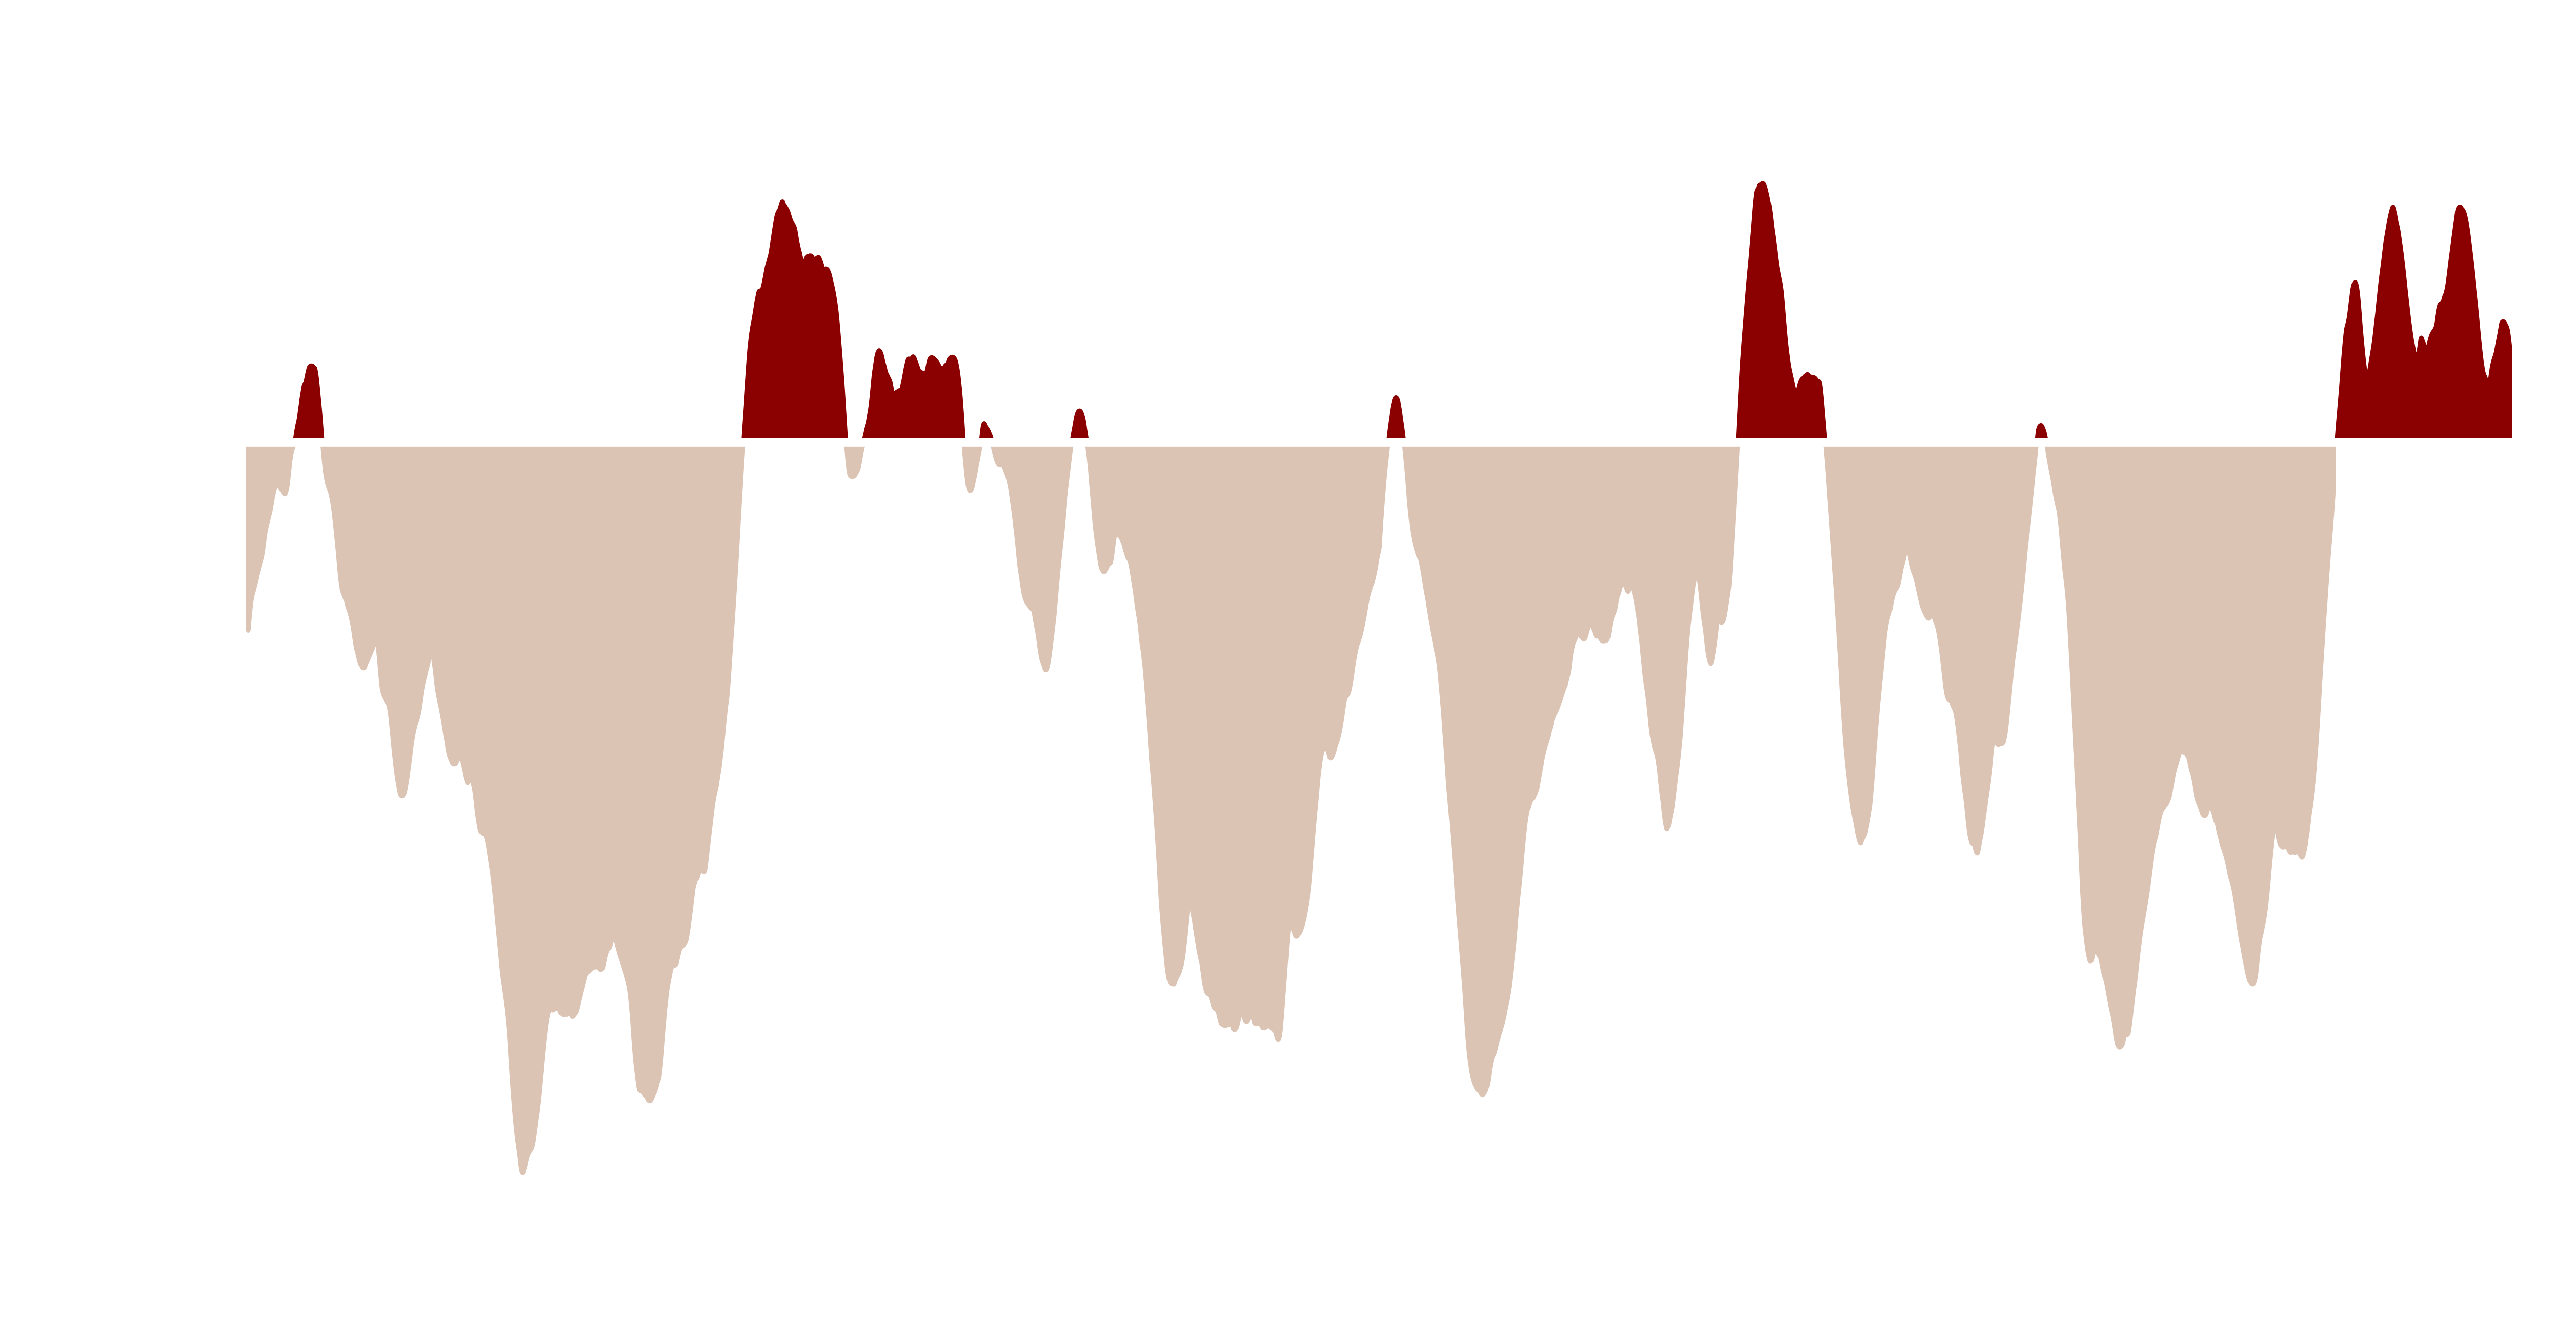

In [22]:
window_size = 500
smooth_percentages = np.convolve(percentages, np.ones(window_size)/window_size, mode='valid')
timestamps_in_minutes_extended = np.linspace(0, 90, len(percentages))

plt.figure(figsize=(10, 5), facecolor='none', dpi=600)
plt.plot(timestamps_in_minutes_extended[window_size-1:], smooth_percentages, color='White', linewidth=0)
plt.axhline(y=50, color='white', linestyle='-', linewidth=2)
plt.vlines(x=83.5, ymin=25, ymax=50, color='White', linestyle='--', linewidth=3)

plt.fill_between(timestamps_in_minutes_extended[window_size-1:], smooth_percentages, 50, 
                 where=(smooth_percentages >= 50), color='#8B0000', alpha=1)
plt.fill_between(timestamps_in_minutes_extended[window_size-1:], smooth_percentages, 50, 
                 where=(smooth_percentages < 50), color='#dcc4b4', alpha=1)

ax = plt.gca()
ax.set_facecolor('none')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', which='both', length=0, colors='white',labelsize=15)     

ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))
ax.set_xticks([t for t in np.linspace(0, 90, num=7) if t > 0])  # Adjust 'num' to control tick density
ax.set_yticks([25, 35, 50, 65])
plt.xlim(0, 90)

plt.savefig('figures/pitch_control_visualization.png', transparent=True, bbox_inches='tight', pad_inches=0.1)
plt.show()
plt.close()

## 3.2 Heatmap

Heatmap of ball receipts for Belgium:

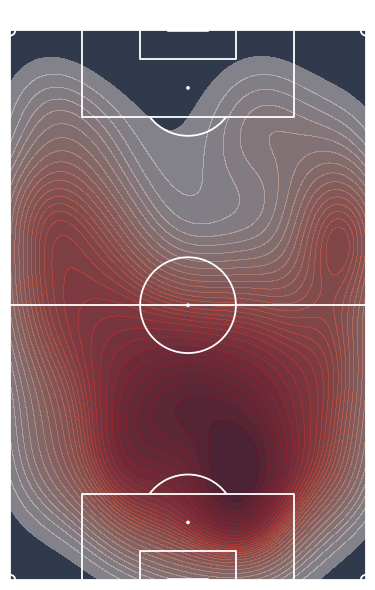

In [25]:
# Configuration: Choose which team to analyze (set to away_team or home_team)
ANALYZED_TEAM = away_team  # Change this to analyze different team

receipts = df_event[(df_event['type'] == 'Ball Receipt*') & (df_event['possession_team'] == ANALYZED_TEAM)]

pitch = VerticalPitch(pitch_type='uefa', pitch_color='#31394d', line_color='white', linewidth=1.3, corner_arcs=True, line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 6))

sns.kdeplot(
    y=receipts['location_x'],
    x=receipts['location_y'],
    fill=True, cmap='Reds', levels=30, alpha=0.4, ax=ax,  
)

plt.xlim(0, 68)
plt.ylim(0, 105)
plt.title(f"{ANALYZED_TEAM} - Ball Receipt Heatmap", color='white', fontsize=12)

plt.show()

# save as png
fig.savefig(f'figures/{ANALYZED_TEAM.lower()}_heatmap.png', dpi=600, bbox_inches='tight', facecolor='#31394d')

# 4. Offensive Behavior

## 4.1 Shot Map

In [26]:
shots = df_event[(df_event['type'] == 'Shot') & (df_event['possession_team'] == ANALYZED_TEAM)]
shots = shots[['timestamp', 'location_x', 'location_y', 'player', 'shot_body_part', 'shot_deflected', 'shot_end_location', 'shot_key_pass_id', 'shot_outcome', 'shot_statsbomb_xg', 'shot_type' ]]

In [27]:
total_shots = len(shots)
total_goals = len(shots[shots['shot_outcome'] == 'Goal'])
total_xg = shots['shot_statsbomb_xg'].sum()
xg_per_shot = total_xg / total_shots

shots['distance_to_goal'] = np.sqrt((shots['location_x'] - 105)**2 + (shots['location_y'] - 34)**2)

# Compute the average shot distance
average_shot_distance = shots['distance_to_goal'].mean()


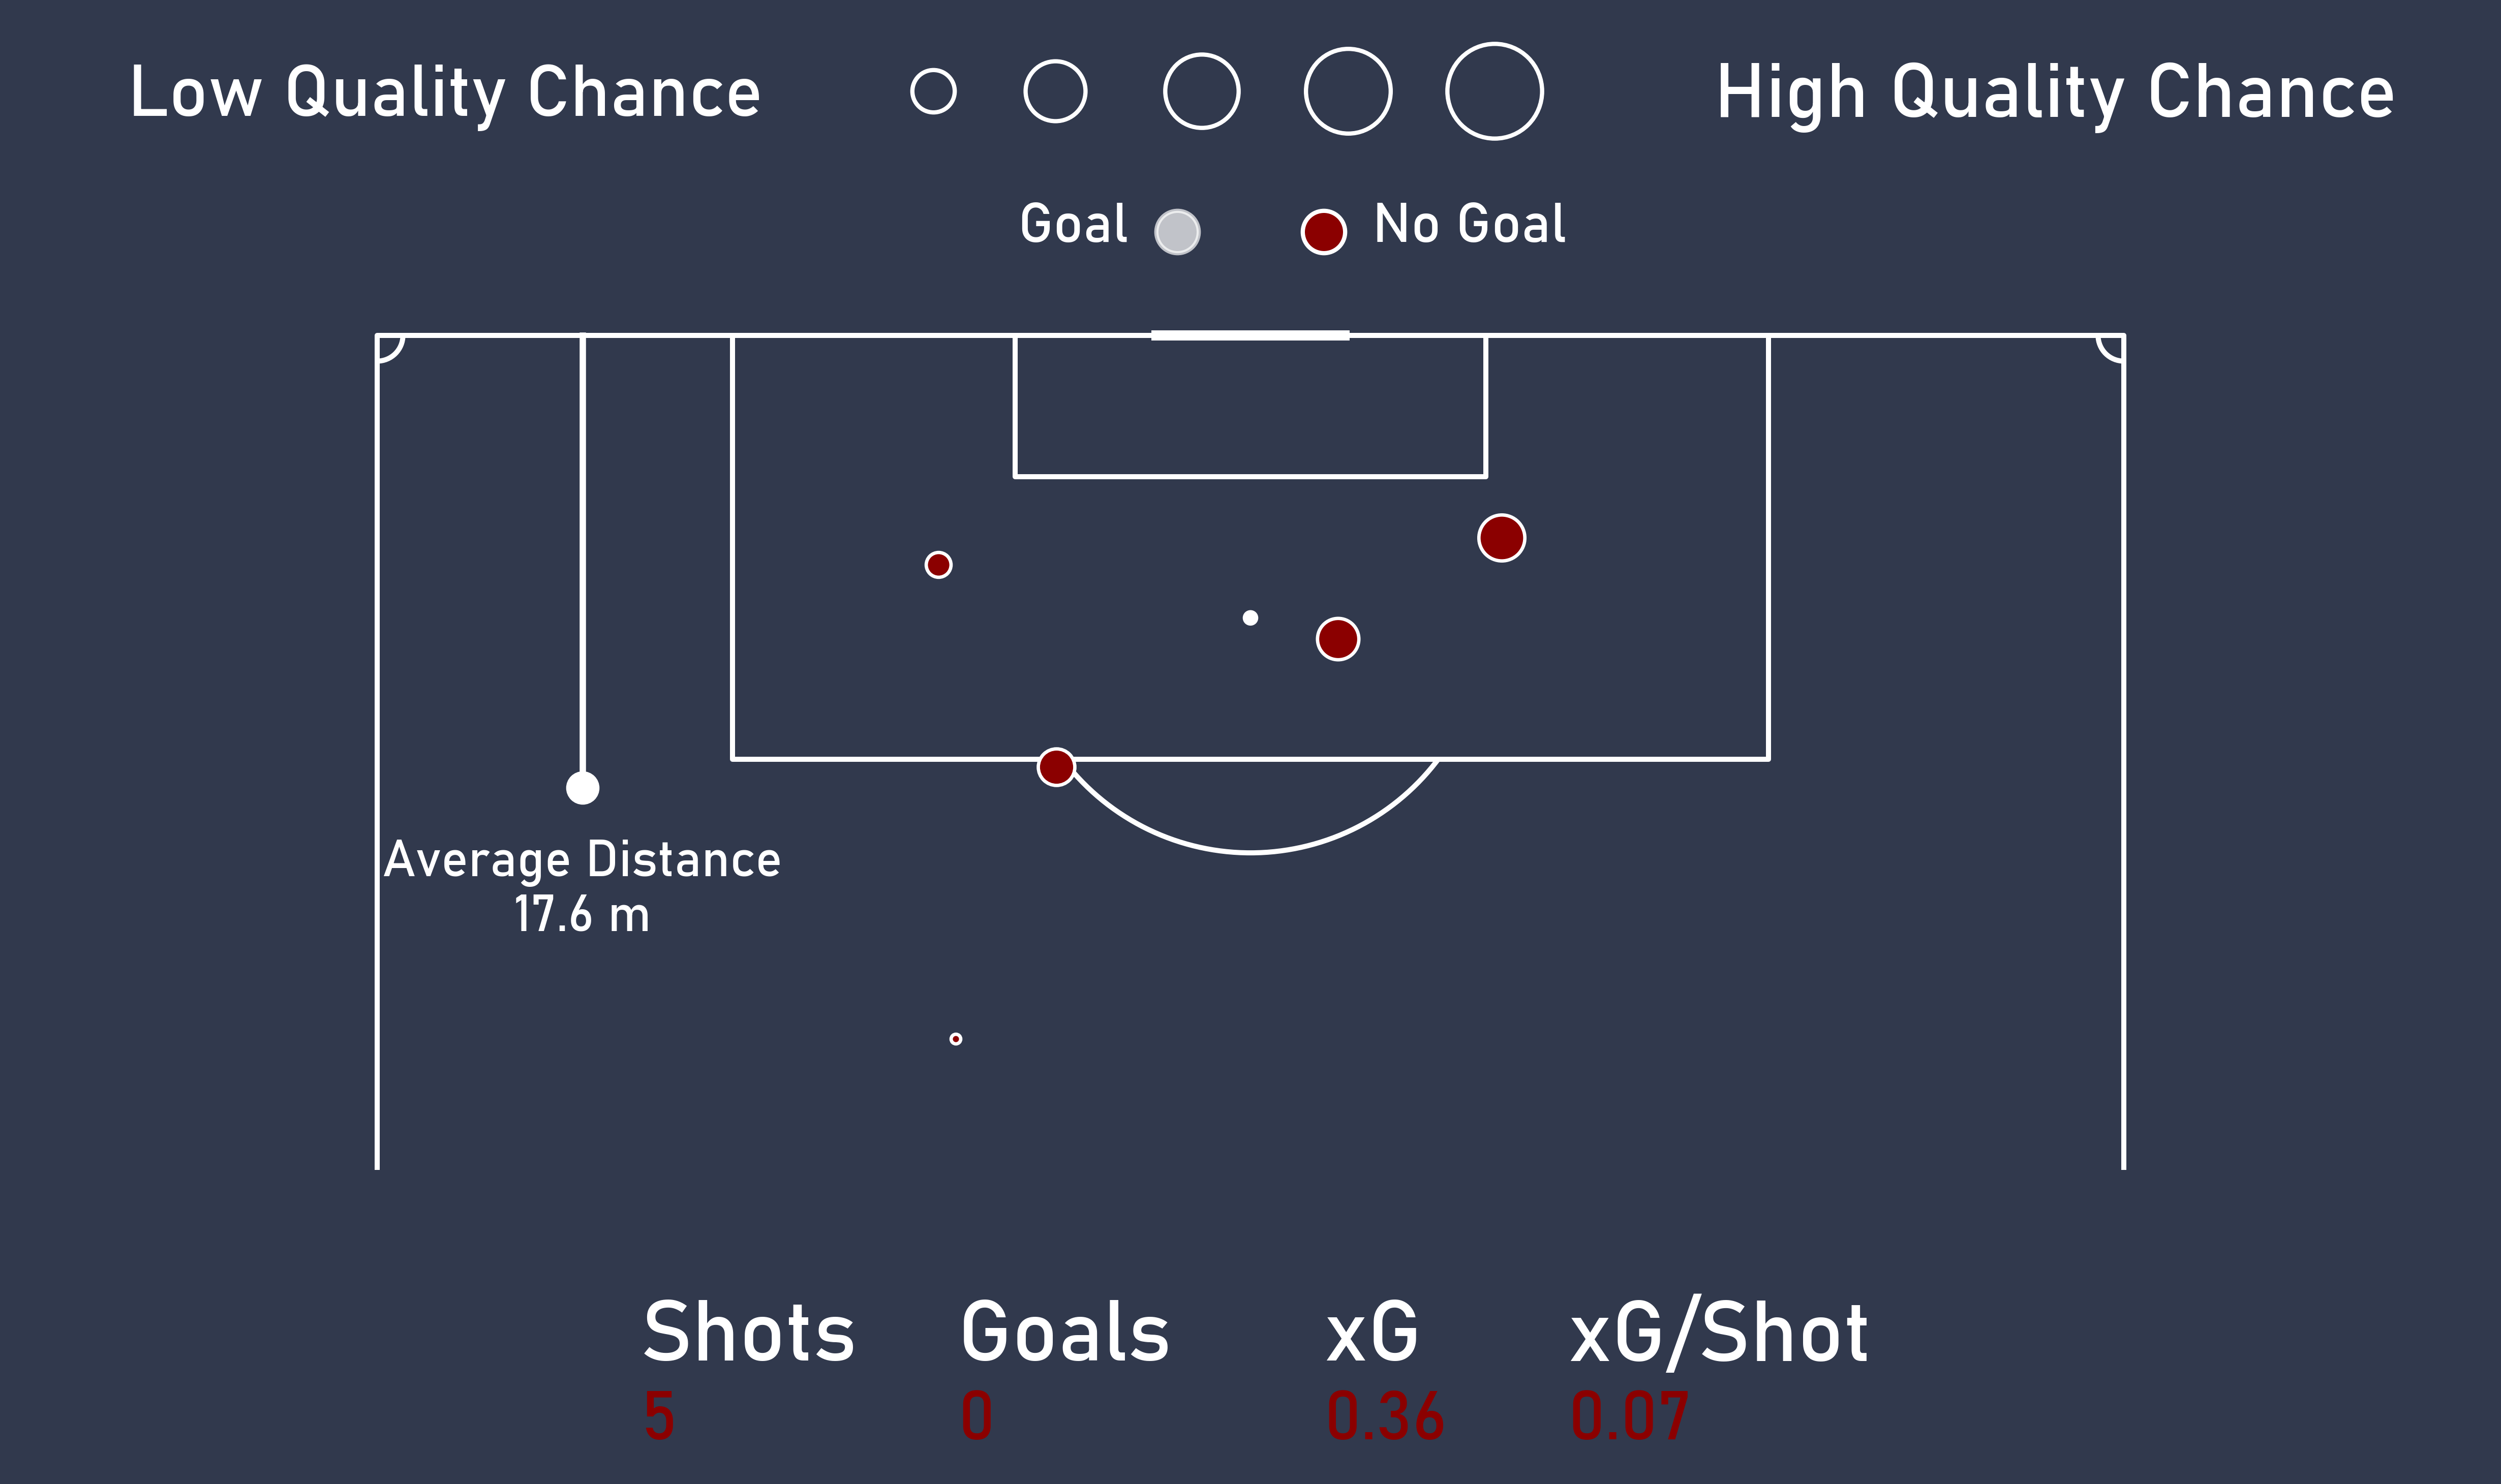

In [28]:
fig_shots = plt.figure(figsize=(8, 11), dpi=600)
fig_shots.patch.set_facecolor('#31394d')

ax1 = fig_shots.add_axes([0, 0.55, 1, 0.1])
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off') 

ax1.text(0.17, 0.8, 'Low Quality Chance', fontsize=17, color='white', ha='center', va='center', fontname='Bahnschrift')

ax1.scatter(0.37, 0.82, s=100, color = '#31394d', edgecolors='white', linewidth=1)
ax1.scatter(0.42, 0.82, s=200, color = '#31394d', edgecolors='white', linewidth=1)
ax1.scatter(0.48, 0.82, s=300, color = '#31394d', edgecolors='white', linewidth=1)
ax1.scatter(0.54, 0.82, s=400, color = '#31394d', edgecolors='white', linewidth=1)
ax1.scatter(0.6, 0.82, s=500, color = '#31394d', edgecolors='white', linewidth=1)


ax1.text(0.83, 0.8, 'High Quality Chance', fontsize=18, color='white', ha='center', va='center', fontname='Bahnschrift')

ax1.text(
    x=0.45, 
    y=0.37, 
    s=f'Goal', 
    fontsize=13, 
    fontproperties='Bahnschrift', 
    color='white', 
    ha='right'
)
ax1.scatter(
    x=0.47, 
    y=0.4, 
    s=100, 
    color='white', 
    edgecolor='white', 
    linewidth=1,
    alpha=.7
)


ax1.scatter(
    x=0.53, 
    y=0.4, 
    s=100, 
    color='#8b0000', 
    edgecolor='white', 
    linewidth=1
)

ax1.text(
    x=0.55, 
    y=0.37, 
    s=f'No Goal', 
    fontsize=13, 
    fontproperties='Bahnschrift', 
    color='white', 
    ha='left'
)

ax2 = fig_shots.add_axes([0.1, 0.30, 0.8, 0.3])
ax2.set_facecolor('#31394d')
ax2.axis('off')  # Hide axes

pitch = VerticalPitch(pitch_type='uefa', half=True, pitch_color='#31394d', line_color='white', linewidth=1.2, corner_arcs=True, axis=True, label=True,  pad_bottom=-20)
pitch.draw(ax=ax2)

ax2.scatter(x=60, y=105-average_shot_distance, s=50, linewidth=.8, color='white')
ax2.plot([60, 60], [(105-average_shot_distance), 105], color='white', linewidth=1.5)
ax2.text(60, 105-average_shot_distance-4, f'Average Distance\n{average_shot_distance:.1f} m', fontsize=12, color='white', ha='center', va='center', fontname='Bahnschrift')

for x in shots.to_dict(orient='records'):
	pitch.scatter(x['location_x'], x['location_y'], color='#8b0000', edgecolors='White', linewidth=0.8, s=900*x['shot_statsbomb_xg'], ax=ax2)

ax3 = fig_shots.add_axes([0, 0.23, 1, 0.05])
ax3.set_facecolor('#31394d')
ax3.axis('off') 

ax3.text(0.25,0.6,s='Shots',fontsize=20,color='white',ha='left',va='center',fontname='Bahnschrift')
ax3.text(0.25,0,s=f'{total_shots}',fontsize=16,color='#8b0000',ha='left',fontname='Bahnschrift',fontweight='bold')

ax3.text(0.38,0.6,s='Goals',fontsize=20,color='white',ha='left',va='center',fontname='Bahnschrift')
ax3.text(0.38,0,s=f'{total_goals}',fontsize=16,color='#8b0000',ha='left',fontname='Bahnschrift', fontweight='bold')

ax3.text(0.53,0.6,s='xG',fontsize=20,color='white',ha='left',va='center',fontname='Bahnschrift')
ax3.text(0.53,0,s=f'{total_xg:.2f}',fontsize=16,color='#8b0000',ha='left',fontname='Bahnschrift', fontweight='bold')

ax3.text(0.63,0.6,s='xG/Shot',fontsize=20,color='white',ha='left',va='center',fontname='Bahnschrift')
ax3.text(0.63,0,s=f'{xg_per_shot:.2f}',fontsize=16,color='#8b0000',ha='left',fontname='Bahnschrift', fontweight='bold')


plt.savefig(f'figures/{ANALYZED_TEAM.lower()}_shots.png', dpi=600, facecolor='#31394d', bbox_inches='tight')
plt.show()

## 4.2 Main Passes Map

Divide the pitch into grid areas and count passes between zones to identify main passing patterns.

In [29]:
df_passes = df_event[(df_event['type'] == 'Pass') & (df_event['possession_team'] == ANALYZED_TEAM)]

In [30]:
pitch_length = 105
pitch_width = 68

x_blocks = 6
y_blocks = 5

x_bins = np.linspace(0, pitch_length, x_blocks + 1)
y_bins = np.linspace(0, pitch_width, y_blocks + 1)

# determine block coordinates
def get_block(x, y, x_bins, y_bins):
    x_block = np.digitize(x, x_bins) - 1
    y_block = np.digitize(y, y_bins) - 1
    x_block = max(0, min(x_blocks - 1, x_block))
    y_block = max(0, min(y_blocks - 1, y_block))
    return (x_block, y_block)

# Pass network matrix
pass_network = np.zeros((x_blocks * y_blocks, x_blocks * y_blocks), dtype=int)

for _, row in df_passes.iterrows():
    start_block = get_block(row['location_x'], row['location_y'], x_bins, y_bins)
    end_block = get_block(row['pass_end_location_x'], row['pass_end_location_y'], x_bins, y_bins)
    
    if start_block != end_block:
        start_idx = start_block[0] * y_blocks + start_block[1]
        end_idx = end_block[0] * y_blocks + end_block[1]
        pass_network[start_idx, end_idx] += 1

block_labels = [f"{x}_{y}" for x in range(x_blocks) for y in range(y_blocks)]
pass_network_df = pd.DataFrame(pass_network, index=block_labels, columns=block_labels)

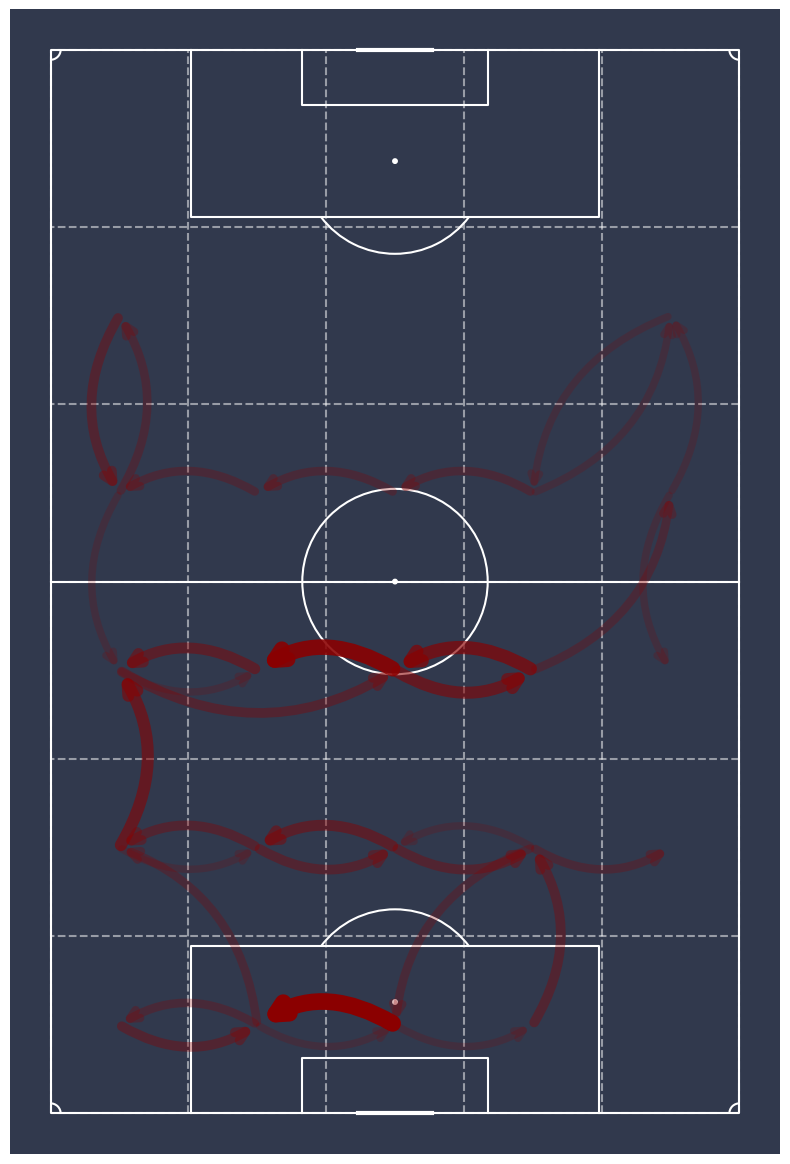

In [31]:
pitch = VerticalPitch(pitch_type='uefa', pitch_color='#31394d', line_color='white',
              linewidth=1.5, corner_arcs=True)
fig, ax = pitch.draw(figsize=(8, 12)) 

for x in x_bins:
    ax.plot([0, pitch_width], [x, x], color='white', linestyle='--', linewidth=1.5, alpha=0.5)
for y in y_bins:
    ax.plot([y, y], [0, pitch_length], color='white', linestyle='--', linewidth=1.5, alpha=0.5)

x_centers = (x_bins[:-1] + x_bins[1:]) / 2
y_centers = (y_bins[:-1] + y_bins[1:]) / 2

max_passes = np.max(pass_network)
min_passes = np.min(pass_network[pass_network > 0])
norm_alpha = plt.Normalize(vmin=min_passes, vmax=max_passes)

# Draw arrows
for i in range(x_blocks * y_blocks):
    for j in range(x_blocks * y_blocks):
        if pass_network[i, j] > 3:
           
            start_x_block = i // y_blocks
            start_y_block = i % y_blocks
            end_x_block = j // y_blocks
            end_y_block = j % y_blocks

            start_y = x_centers[start_x_block]
            start_x = y_centers[start_y_block]
            end_y = x_centers[end_x_block]
            end_x = y_centers[end_y_block]

            pass_count = pass_network[i, j]
            alpha = norm_alpha(pass_count)**1.3
            color = '#8B0000'
            width = 0.1 + 0.5 * (pass_count / max_passes)
            arrow = FancyArrowPatch(
                (start_x, start_y), (end_x, end_y),
                connectionstyle="arc3,rad=0.3",
                arrowstyle='->',
                color=color,
                alpha=alpha,
                linewidth=width * 20,
                mutation_scale=10 + 20 * width,
                zorder=3
            )
            ax.add_patch(arrow)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.tight_layout()

plt.savefig("figures/pass_flows.png", format="png", dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


## 4.3 Passes to the Box

In [32]:
passes_to_box = df_passes[(df_passes['pass_end_location_x'] > 88.5) & 
		  (df_passes['pass_end_location_y'] > 13.84) & 
		  (df_passes['pass_end_location_y'] < 54.16)]

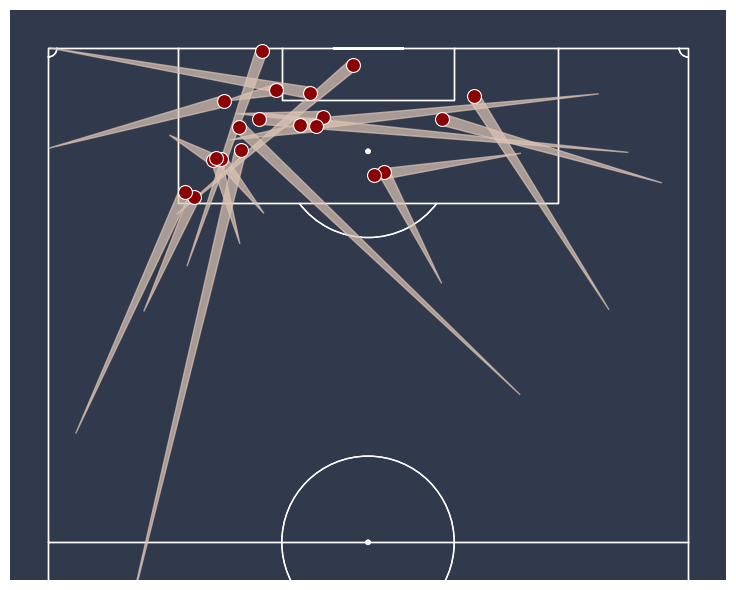

In [33]:
pitch = VerticalPitch(half=True, pitch_type='uefa', pitch_color='#31394d', line_color='white', linewidth=1, corner_arcs=True, line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 6))

for i in passes_to_box.index:
    y0 = passes_to_box['location_x'][i]  # Pass origin
    x0 = passes_to_box['location_y'][i]  # Pass origin
    y1 = passes_to_box['pass_end_location_x'][i]  # Pass destination 
    x1 = passes_to_box['pass_end_location_y'][i]  # Pass destination 
    
    # Direction vector 
    dx = x1 - x0
    dy = y1 - y0
    length = np.hypot(dx, dy)
    if length == 0:
        continue 
    
    perp_x = -dy / length
    perp_y = dx / length
    
    start_width = 0.0    # Narrow at origin
    end_width = 1.2      # Wide at destination
    
    x_start_left = x0 - perp_x * start_width / 2
    y_start_left = y0 - perp_y * start_width / 2
    x_start_right = x0 + perp_x * start_width / 2
    y_start_right = y0 + perp_y * start_width / 2
    
    x_end_left = x1 - perp_x * end_width / 2
    y_end_left = y1 - perp_y * end_width / 2
    x_end_right = x1 + perp_x * end_width / 2
    y_end_right = y1 + perp_y * end_width / 2
    
    verts = [
        (x_start_left, y_start_left),
        (x_start_right, y_start_right),
        (x_end_right, y_end_right),
        (x_end_left, y_end_left),
        (x_start_left, y_start_left)  # Close the polygon
    ]
    
    ax.add_patch(PolygonPatch(verts, closed=True, color='#dcc4b4', alpha=0.7, zorder=5))
    ax.scatter(x1, y1, color='#8b0000', edgecolors='white', linewidth=0.8, s=100, alpha=1, zorder=6)

pitch.draw(ax=ax)

plt.savefig("figures/passes_to_box.png", format="png", dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

# 5. Final Report Output

Combine all visualizations into a single report layout.

## 5.1 Configuration

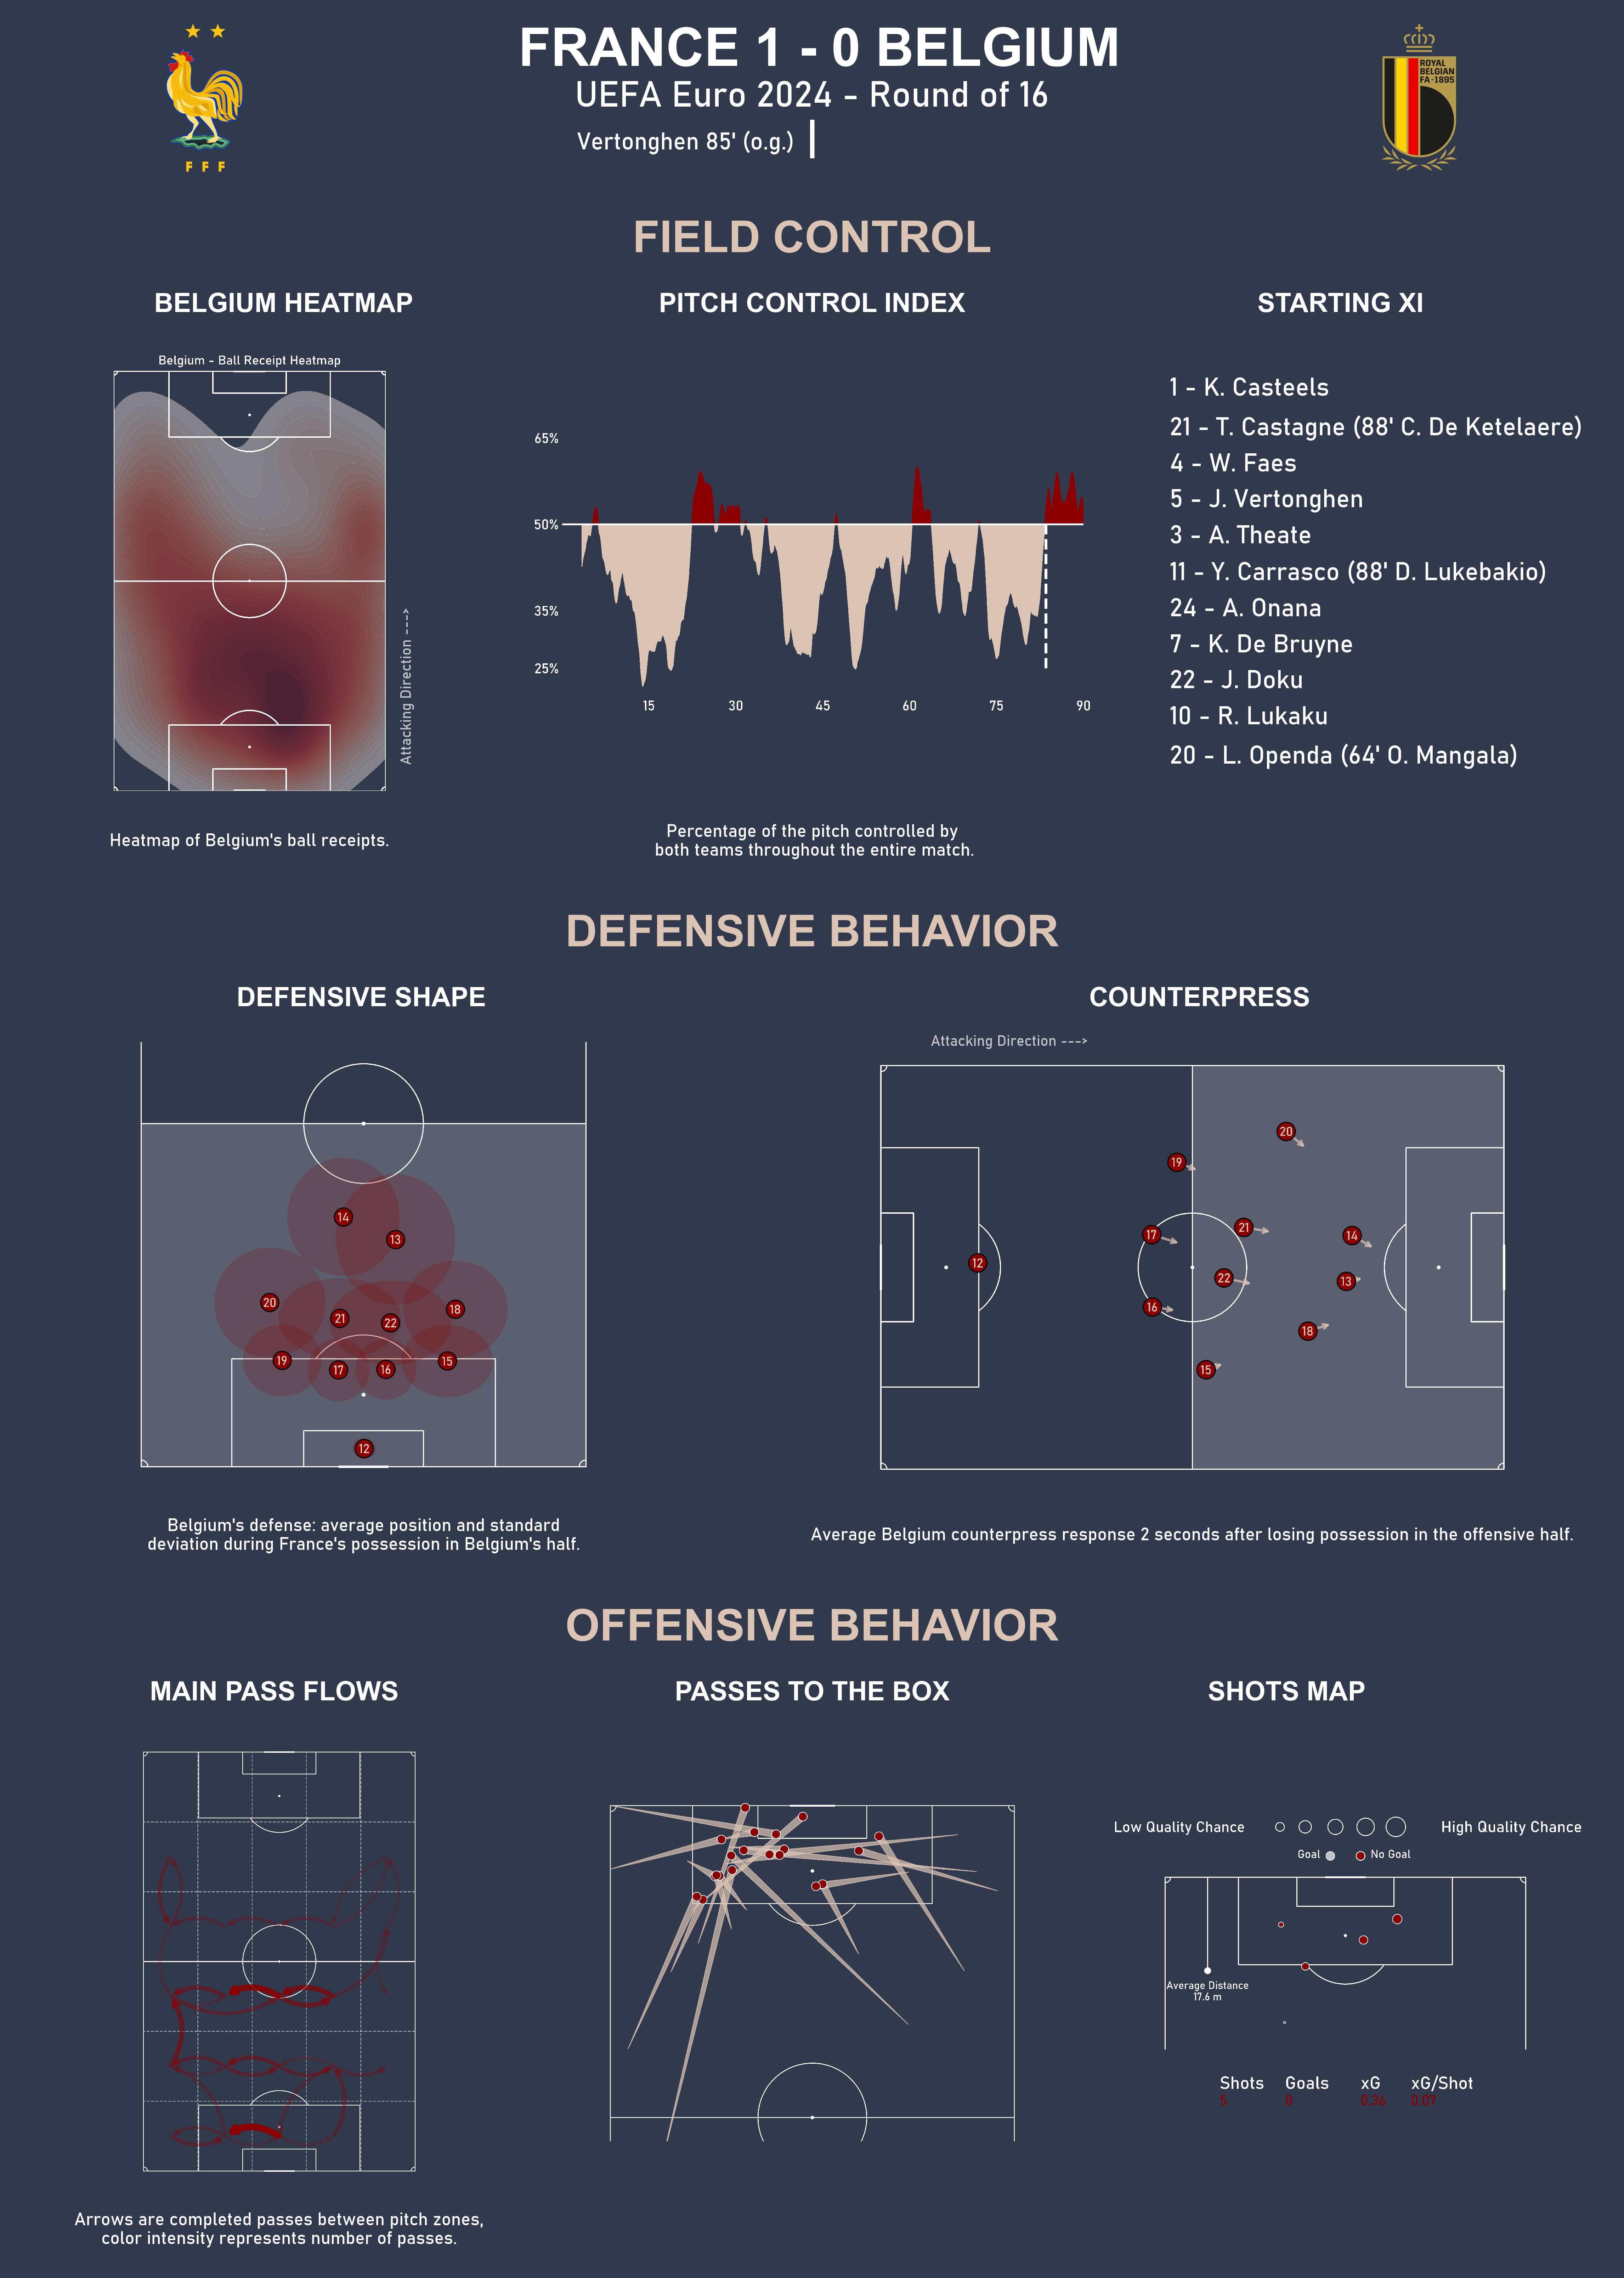

In [34]:
# ----- Custom colors and fonts -----
title_color = "#FFFFFF"
background_color = "#31394d"
text_color = "#FFFFFF"
accent_color = "#FF5733"

title_font = "Arial"
body_font = "Bahnschrift"

# Formation text
formation_text = "1 - K. Casteels\n21 - T. Castagne (88' C. De Ketelaere)\n4 - W. Faes\n5 - J. Vertonghen\n3 - A. Theate\n11 - Y. Carrasco (88' D. Lukebakio)\n24 - A. Onana\n7 - K. De Bruyne\n22 - J. Doku\n10 - R. Lukaku\n20 - L. Openda (64' O. Mangala)"

# ----- Load team logos once -----
url1 = "https://logos-world.net/wp-content/uploads/2024/06/Belgium-National-Football-Team-Logo.png"
url2 = "https://logos-world.net/wp-content/uploads/2024/06/France-National-Football-Team-Logo.png"
img1 = Image.open(BytesIO(requests.get(url1).content))
img2 = Image.open(BytesIO(requests.get(url2).content))

# ----- A4 Figure Setup -----
fig = plt.figure(figsize=(8.27, 11.69), dpi=600)
fig.patch.set_facecolor(background_color)
gs = fig.add_gridspec(nrows=13, ncols=4, height_ratios=[0.17, 0.08, 0.06, 0.5, 0.06, 0.08, 0.06, 0.5, 0.06, 0.08, 0.06, 0.5, 0.06])
gs.update(left=0.05, right=0.95, top=0.95, bottom=0.05, hspace=0.1, wspace=0.1)


def stylize_ax(ax, border=True, grid=True):
    ax.set_facecolor(background_color)
    ax.set_xticks([])
    ax.set_yticks([])
    if grid:
        ax.grid(True, color='white', linestyle='-', linewidth=0.3)
    if border:
        ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                               linewidth=1.2, edgecolor="white", facecolor='none'))

### SECTION 1: TITLE ###
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_facecolor(background_color)
ax_title.axis('off')
ax_title.text(0.5, 0.8, " FRANCE 1 - 0 BELGIUM", fontsize=18, fontweight='bold',
              ha='center', va='center', color=text_color, fontname=title_font)

# Subtitles & goal
ax_title.text(0.5, 0.5, "UEFA Euro 2024 - Round of 16", fontsize=12,
              ha='center', va='center', color=text_color, fontname=body_font)
ax_title.text(0.5, 0.2, "|", fontsize=15, ha='center', va='center', color=text_color, fontname=body_font)
ax_title.text(0.42, 0.21, "Vertonghen 85' (o.g.)", fontsize=8,
              ha='center', va='center', color=text_color, fontname=body_font)

# Logos
ax_logo1 = fig.add_subplot(gs[0, 3])
ax_logo2 = fig.add_subplot(gs[0, 0])
for ax, img in zip([ax_logo1, ax_logo2], [img1, img2]):
    ax.imshow(img)
    ax.axis("off")


### SECTION 2: FIELD CONTROL ###
ax_fc_title = fig.add_subplot(gs[1, :])
ax_fc_title.set_facecolor(background_color)
ax_fc_title.axis('off')
ax_fc_title.text(0.5, 0.3, "FIELD CONTROL", fontsize=15, ha='center', va='center',
                 color='#dcc4b4', fontname=title_font, weight='bold')

ax_fc_sub = fig.add_subplot(gs[2, :])
ax_fc_sub.set_facecolor(background_color)
ax_fc_sub.axis('off')
x_pos = [0.166, 0.5, 0.834]
labels = ["BELGIUM HEATMAP", "PITCH CONTROL INDEX", "STARTING XI"]
for x, label in zip(x_pos, labels):
    ax_fc_sub.text(x, 0.5, label, fontsize=9, ha='center', va='center',
                   color=text_color, fontname=title_font, weight='bold')

# 3-column visuals
gs_sub_2 = gs[3, :].subgridspec(1, 3, wspace=0.1, width_ratios=[0.8, 1, 0.8])
ax1 = fig.add_subplot(gs_sub_2[0])
ax2 = fig.add_subplot(gs_sub_2[1])
ax3 = fig.add_subplot(gs_sub_2[2])

for ax in [ax1, ax2]:
    ax.imshow(plt.imread('figures/belgium_heatmap.png') if ax == ax1 else plt.imread('figures/pitch_control_visualization.png'),
              aspect='equal', interpolation='none')
    ax.axis('off')
    
ax1.text(1.05, 0.25, 'Attacking Direction --->', rotation='vertical',
         fontsize=5, ha='center', va='center', color=text_color, fontname=body_font, alpha=0.7,transform=ax1.transAxes)

ax3.set_facecolor(background_color)
ax3.axis('off')
ax3.text(0.05, 0.5, formation_text, fontsize=8.5, ha='left', va='center',
         color=text_color, fontname=body_font, linespacing=1.7)

# Comments
gs_comm_2 = gs[4, :].subgridspec(1, 3, wspace=0.1, width_ratios=[0.8, 1, 0.8])
ax1 = fig.add_subplot(gs_comm_2[0])
ax2 = fig.add_subplot(gs_comm_2[1])
ax1.set_facecolor(background_color)
ax2.set_facecolor(background_color)
ax1.axis('off')
ax2.axis('off')
ax1.text(0.5, 0.5, "Heatmap of Belgium's ball receipts.", color="white", fontsize=6, ha='center', va='center')
ax2.text(0.5, 0.5, "Percentage of the pitch controlled by\n both teams throughout the entire match.", color="white", fontsize=6, ha='center', va='center')


### SECTION 3: DEFENSIVE BEHAVIOR ###
ax_fc_title = fig.add_subplot(gs[5, :])
ax_fc_title.set_facecolor(background_color)
ax_fc_title.axis('off')
ax_fc_title.text(0.5, 0.3, "DEFENSIVE BEHAVIOR", fontsize=15, ha='center', va='center',
                 color='#dcc4b4', fontname=title_font, weight='bold')

ax_fc_sub = fig.add_subplot(gs[6, :])
ax_fc_sub.set_facecolor(background_color)
ax_fc_sub.axis('off')
x_pos = [0.215,0.745]
labels = ["DEFENSIVE SHAPE", "COUNTERPRESS"]
for x, label in zip(x_pos, labels):
    ax_fc_sub.text(x, 0.5, label, fontsize=9, ha='center', va='center',
                   color=text_color, fontname=title_font, weight='bold')

gs_sub_3 = gs[7, :].subgridspec(1, 2, wspace=0.1, width_ratios=[0.5, 0.6])
ax1 = fig.add_subplot(gs_sub_3[0])
ax2 = fig.add_subplot(gs_sub_3[1])
ax1.imshow(plt.imread('figures/defensive_shape.png'), aspect='equal', interpolation='none')
ax1.axis('off')
ax2.imshow(plt.imread('figures/transitions.png'), aspect='equal', interpolation='none')
ax2.text(1.8, 1, 'Attacking Direction --->',
         fontsize=5, ha='center', va='center', color=text_color, fontname=body_font, alpha=0.7,transform=ax1.transAxes)
ax2.axis('off')

# Comments
gs_comm_3 = gs[8, :].subgridspec(1, 2, wspace=0.1, width_ratios=[0.5, 0.6])
ax1 = fig.add_subplot(gs_comm_3[0])
ax2 = fig.add_subplot(gs_comm_3[1])
ax1.set_facecolor(background_color)
ax2.set_facecolor(background_color)
ax1.axis('off')
ax2.axis('off')
ax1.text(0.5, 0.5, "Belgium's defense: average position and standard\ndeviation during France's possession in Belgium's half.", color="white", fontsize=6, ha='center', va='center')
ax2.text(0.5, 0.5, "Average Belgium counterpress response 2 seconds after losing possession in the offensive half.", color="white", fontsize=6, ha='center', va='center')


### SECTION 4: OFFENSIVE BEHAVIOR ###
ax_fc_title = fig.add_subplot(gs[9, :])
ax_fc_title.set_facecolor(background_color)
ax_fc_title.axis('off')
ax_fc_title.text(0.5, 0.3, "OFFENSIVE BEHAVIOR", fontsize=15, ha='center', va='center',
                 color="#dcc4b4", fontname=title_font, weight='bold')

ax_fc_sub = fig.add_subplot(gs[10, :])
ax_fc_sub.set_facecolor(background_color)
ax_fc_sub.axis('off')
x_pos = [0.16,0.5,0.8]
labels = ["MAIN PASS FLOWS","PASSES TO THE BOX", "SHOTS MAP"]
for x, label in zip(x_pos, labels):
    ax_fc_sub.text(x, 0.5, label, fontsize=9, ha='center', va='center',
                   color=text_color, fontname=title_font, weight='bold')

gs_sub_4 = gs[11, :].subgridspec(1, 3, wspace=0.1, width_ratios=[0.8, 0.7, 0.8])
ax1 = fig.add_subplot(gs_sub_4[0])
ax2 = fig.add_subplot(gs_sub_4[1])
ax3 = fig.add_subplot(gs_sub_4[2])
ax1.imshow(plt.imread('figures/pass_flows.png'), aspect='equal', interpolation='none')
ax1.axis('off')
ax2.imshow(plt.imread('figures/passes_to_box.png'), aspect='equal', interpolation='none')
ax2.axis('off')
ax3.imshow(plt.imread('figures/belgium_shots.png'), aspect='equal', interpolation='none')
ax3.axis('off')

# Comments
gs_comm_4 = gs[12, :].subgridspec(1, 3, wspace=0.1, width_ratios=[0.8, 0.7, 0.8])
ax1 = fig.add_subplot(gs_comm_4[0])
ax2 = fig.add_subplot(gs_comm_4[1])
ax3 = fig.add_subplot(gs_comm_4[2])
ax1.set_facecolor(background_color)
ax2.set_facecolor(background_color)
ax3.set_facecolor(background_color)
ax1.axis('off')
ax2.axis('off')
ax3.axis('off')
ax1.text(0.5, 0.5, "Arrows are completed passes between pitch zones,\ncolor intensity represents number of passes.", color="white", fontsize=6, ha='center', va='center')

# Final Layout Adjustments
plt.subplots_adjust(left=0.05, right=0.95, top=0.98, bottom=0.02, hspace=0.2)
plt.savefig("match_report.pdf", format="pdf", dpi=600, bbox_inches="tight", facecolor=background_color)
plt.show()